
# Pricing No Vida con GLM 

## Supuestos: Preparación de Datos, Exposición y Dispersión

**Autor:** Eric Daniel Hernández Jardón  

**Tema:** Preparación de datos, exposición, dispersión, heterocedasticidad y segmentación (contexto Autos).
**Objetivo del cuaderno:** Entender la implementación previa a un modelado GLM, usando los supuestos de: exposición, segmentación y chequeos de sobredispersión.

**Tabla de contenido**
0. Contexto
1. Setup y datos (1) `01_merge_data.py` (unión de pólizas–siniestros))
2. Regresión lineal y heterocedasticidad (`02_lm_glm.py` (regresión lineal y chequeos de heterocedasticidad))
3. Simulación de exposición y escenarios de cancelación (intuición del offset)  (`03_exposicion.py` (cálculo de exposición))
4. Ventajas de la segmentación (edad continua, factor, cortes, splines)   (`04_segmentacion.py` (tablas por segmentos; frecuencia/severidad))
5. Sobredispersión y elección de la distribución (Poisson vs QP/ZIP/NB)  ( (`05_dispersión.py` (tablas por segmentos; frecuencia/severidad)))
6. Bitácora de aprendizaje y ejercicio






## 0. Contexto real (Autos en MX) para anclar conceptos
Tomaremos referencias sectoriales (ficticias pero realistas) para **tres coberturas**:
- **Daños Materiales (DM):** Frecuencia ≈ 15.9%, Severidad ≈ 22,023 MXN  
- **Responsabilidad Civil (RC):** Frecuencia ≈ 8.5%, Severidad ≈ 17,147 MXN  
- **Robo Total (RT):** Frecuencia ≈ 0.42%, Severidad ≈ 206,984 MXN

Con esto, la **prima pura promedio** (por vehículo) sería:
- DM: 0.159 × 22,023 ≈ 3,502 MXN
- RC: 0.085 × 17,147 ≈ 1,458 MXN
- RT: 0.0042 × 206,984 ≈ 869 MXN
- **Total** ≈ **5,828 MXN**

> Observa la **dispersión natural**: RT tiene **baja frecuencia** pero **severidad muy alta** → las colas de la distribución importan.



## 1. Preparación del entorno y referencia a tus scripts
En esta sección **llamamos** a tus scripts para que los alumnos vean el flujo “real” usado en una aseguradora.


In [5]:

# Si ejecutas en Colab / entorno limpio, sube primero los .py o ajusta las rutas.
# Aquí asumimos que los scripts están en el mismo directorio o en /mnt/data/.
import os, sys
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix
from scipy.stats import norm, poisson

base = "data"
if base not in sys.path:
    sys.path.append(base)

print("Archivos disponibles en data:")
print(os.listdir(base))


Archivos disponibles en data:
['base_trabajo.pkl', 'base_trabajo.RDS', 'siniestros.csv', 'vigor.csv']



### 1.1 Unión de datos (pólizas + siniestros) → `01_merge_data.py`
- Objetivo: resolver **muchos-a-uno** (varios siniestros por póliza), normalizar claves, fechas y tipos.
- Resultado: un **DataFrame integrado** con una fila por póliza (y agregaciones de siniestros).

> **Actividad guiada:** ejecuta el script y revisa los primeros renglones.


In [6]:

# %run permite ejecutar el script como si fuera una celda
# Si no funciona el %run en tu entorno, importa funciones desde el módulo.
try:
    %run 01_merge_data.py
except Exception as e:
    print("Nota: Ajusta la ruta o importa funciones desde 01_merge_data.py. Error:", e)



[glimpse(vigor)]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   NUMPOL               50000 non-null  int64  
 1   EXPO                 50000 non-null  float64
 2   ZONA                 50000 non-null  object 
 3   POTENCIA             50000 non-null  int64  
 4   ANTIGUEDAD_VEHICULO  50000 non-null  int64  
 5   EDAD_CONDUCTOR       50000 non-null  int64  
 6   BONO                 50000 non-null  int64  
 7   MARCA                50000 non-null  int64  
 8   COMBUSTIBLE          50000 non-null  object 
 9   DENSIDAD             50000 non-null  int64  
 10  REGION               50000 non-null  int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 4.2+ MB
None
   NUMPOL  EXPO ZONA  POTENCIA  ANTIGUEDAD_VEHICULO  EDAD_CONDUCTOR  BONO  \
0      27  0.87    C         7                    0              56    50   
1 

In [8]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
pkl_path = os.path.join(DATA_DIR, "base_trabajo.pkl")
rds_path = os.path.join(DATA_DIR, "base_trabajo.RDS")

try:
    if os.path.exists(pkl_path):
        base_trabajo = pd.read_pickle(pkl_path)
    else:
        import pyreadr
        base_trabajo = list(pyreadr.read_r(rds_path).values())[0]
except Exception as e:
    raise FileNotFoundError("Falta data/base_trabajo.pkl o .RDS en la carpeta ./data") from e

display(base_trabajo.head())

,NUMPOL,EXPO,ZONA,POTENCIA,ANTIGUEDAD_VEHICULO,EDAD_CONDUCTOR,BONO,MARCA,COMBUSTIBLE,DENSIDAD,REGION,COD_COBERTURA,MONTO,num_sin
0,27,0.87,C,7,0,56,50,12,D,93,13,NaN,NaN,0
1,115,0.72,D,5,0,45,50,12,E,54,13,NaN,NaN,0
2,121,0.05,C,6,0,37,55,12,D,11,13,NaN,NaN,0
3,142,0.90,C,10,10,42,50,12,D,93,13,NaN,NaN,0
4,155,0.12,C,7,0,59,50,12,E,73,13,NaN,NaN,0


### 1.2 Regresión lineal y chequeos de heterocedasticidad → `02_lm_glm.py`
- Objetivo: entender la **heterocedasticidad** y por qué un modelo lineal puede fallar.
- Resultado: visualizaciones y pruebas estadísticas.

### 1.2.1 Paso a paso del análisis

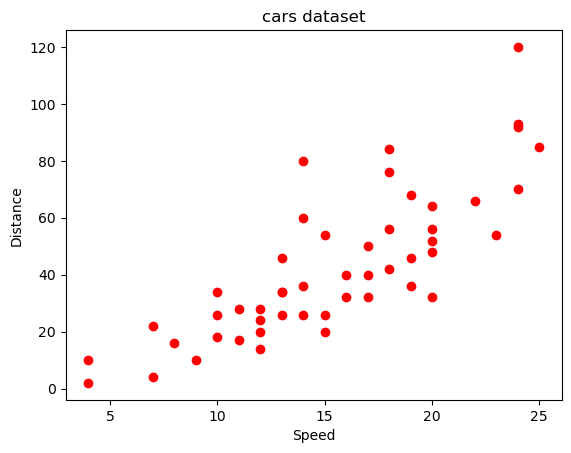

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Fri, 12 Sep 2025   Prob (F-statistic):           1.49e-12
Time:                        07:32:52   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.5791      6.758     -2.601      0.0

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:308: DomainWarning: The identity link function does not respect the domain of the Poisson family.
  warnings.warn((f"The {type(f

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import norm, poisson

# ---------------------------------------------------------
# 0) Datos
# ---------------------------------------------------------
# Dataset "cars" de R → lo replicamos con pandas
from statsmodels.datasets import get_rdataset
cars = get_rdataset("cars").data  # columnas speed, dist

# Scatter simple
plt.scatter(cars["speed"], cars["dist"], c="red")
plt.xlabel("Speed")
plt.ylabel("Distance")
plt.title("cars dataset")
plt.show()

# ---------------------------------------------------------
# 1) Modelos lineales y GLM
# ---------------------------------------------------------
lin_mod = smf.ols("dist ~ speed", data=cars).fit()
print(lin_mod.summary())

gaussian_reg1 = smf.glm("dist ~ speed", data=cars,
                        family=sm.families.Gaussian(sm.families.links.identity())).fit()
print(gaussian_reg1.summary())

gaussian_reg2 = smf.glm("dist ~ speed", data=cars,
                        family=sm.families.Gaussian(sm.families.links.log())).fit()
print(gaussian_reg2.summary())

poisson_reg1 = smf.glm("dist ~ speed", data=cars,
                       family=sm.families.Poisson(sm.families.links.identity())).fit()
print(poisson_reg1.summary())

poisson_reg2 = smf.glm("dist ~ speed", data=cars,
                       family=sm.families.Poisson(sm.families.links.log())).fit()
print(poisson_reg2.summary())

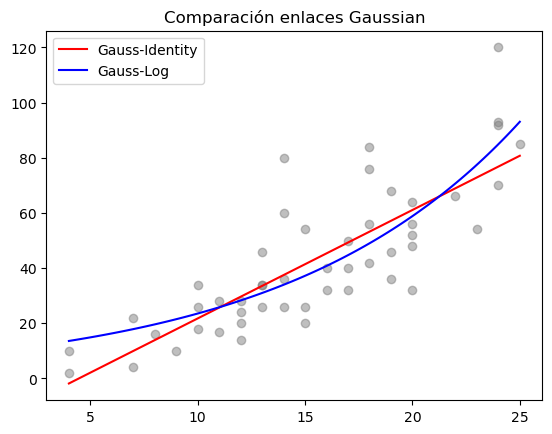

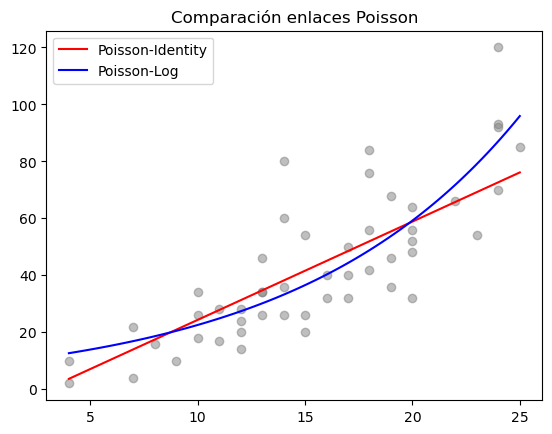

In [10]:
x_pred = pd.DataFrame({"speed": np.linspace(cars["speed"].min(),
                                            cars["speed"].max(), 100)})

plt.scatter(cars["speed"], cars["dist"], c="grey", alpha=0.5)

for model, color, label in [
    (gaussian_reg1, "red", "Gauss-Identity"),
    (gaussian_reg2, "blue", "Gauss-Log")
]:
    mu = model.predict(x_pred)
    plt.plot(x_pred["speed"], mu, color=color, label=label)

plt.legend()
plt.title("Comparación enlaces Gaussian")
plt.show()

plt.scatter(cars["speed"], cars["dist"], c="grey", alpha=0.5)
for model, color, label in [
    (poisson_reg1, "red", "Poisson-Identity"),
    (poisson_reg2, "blue", "Poisson-Log")
]:
    mu = model.predict(x_pred)
    plt.plot(x_pred["speed"], mu, color=color, label=label)
plt.legend()
plt.title("Comparación enlaces Poisson")
plt.show()


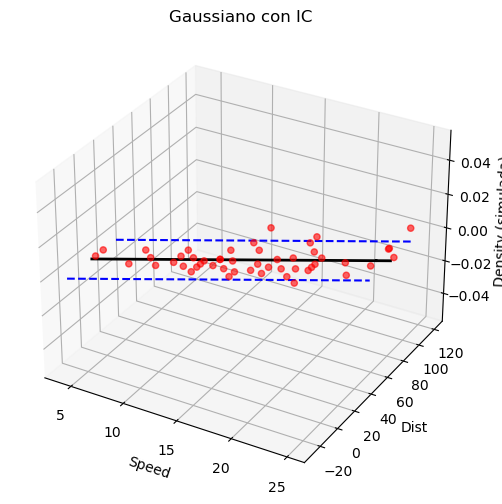

In [11]:
datos_prueba = pd.DataFrame({"speed": cars["speed"]})
mu_hat = gaussian_reg1.predict(datos_prueba)
phi = gaussian_reg1.scale**0.5  # dispersión

y1 = norm.ppf(0.95, loc=mu_hat, scale=phi)
y2 = norm.ppf(0.05, loc=mu_hat, scale=phi)

# Gráfico 3D tipo "persp"
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(cars["speed"], cars["dist"], zs=0, zdir='z', c='red', alpha=0.6)
ax.plot(datos_prueba["speed"], mu_hat, zs=0, zdir='z', color="black", lw=2)
ax.plot(datos_prueba["speed"], y1, zs=0, zdir='z', color="blue", ls="--")
ax.plot(datos_prueba["speed"], y2, zs=0, zdir='z', color="blue", ls="--")

ax.set_xlabel("Speed")
ax.set_ylabel("Dist")
ax.set_zlabel("Density (simulada)")
ax.set_title("Gaussiano con IC")
plt.show()

In [12]:
np.random.seed(1234)
muestra = np.random.choice(len(cars), size=10, replace=False)
datos_muestra = cars.iloc[muestra].sort_values("speed")

vX = datos_muestra["speed"].values
Y = datos_muestra["dist"].values
mu = gaussian_reg1.predict(datos_muestra)

errores = Y - mu
densidad_errores = norm.pdf(errores, 0, phi)
print("Errores:", errores)
print("Densidad normal asociada:", densidad_errores)

Errores: 4      2.119825
6     -3.744993
8     12.255007
13    -5.609810
29    -9.271854
37    10.863328
36   -11.136672
44   -18.866307
45    -6.798715
49     4.268876
dtype: float64
Densidad normal asociada: [0.02569449 0.02518198 0.01888375 0.02427026 0.02162935 0.02021273
 0.01995741 0.01222357 0.02352507 0.02495948]


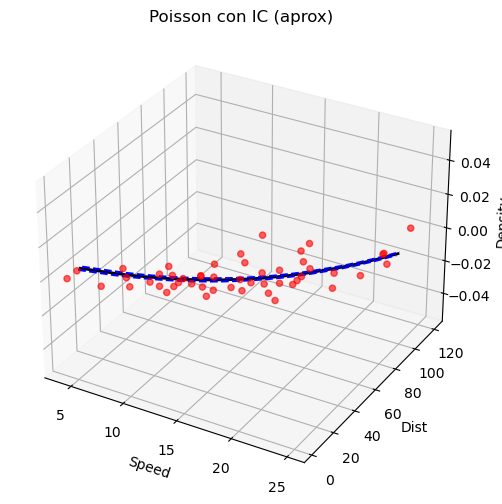

Errores Poisson: 4     -2.596631
6     -4.555642
8     11.444358
13    -3.357483
29    -4.322931
37    14.241220
36    -7.758780
44   -25.084481
45   -17.096707
49   -10.920670
dtype: float64
Densidad Poisson asociada: [0.00000000e+00 0.00000000e+00 4.63517218e-03 0.00000000e+00
 0.00000000e+00 6.95439905e-12 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


In [13]:
mu_hat_poi = poisson_reg2.predict(datos_prueba)
# Nota: en R usas qpois, aquí graficamos IC con aproximación normal
phi_poi = poisson_reg2.scale**0.5

y1_poi = norm.ppf(0.95, loc=mu_hat_poi, scale=phi_poi)
y2_poi = norm.ppf(0.05, loc=mu_hat_poi, scale=phi_poi)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(cars["speed"], cars["dist"], zs=0, zdir='z', c='red', alpha=0.6)
ax.plot(datos_prueba["speed"], mu_hat_poi, zs=0, zdir='z', color="black", lw=2)
ax.plot(datos_prueba["speed"], y1_poi, zs=0, zdir='z', color="blue", ls="--")
ax.plot(datos_prueba["speed"], y2_poi, zs=0, zdir='z', color="blue", ls="--")

ax.set_xlabel("Speed")
ax.set_ylabel("Dist")
ax.set_zlabel("Density")
ax.set_title("Poisson con IC (aprox)")
plt.show()

# Errores Poisson
errores_poi = Y - poisson_reg2.predict(datos_muestra)
densidad_poi = poisson.pmf(np.round(errores_poi).astype(int), mu)
print("Errores Poisson:", errores_poi)
print("Densidad Poisson asociada:", densidad_poi)

### 1.2.2 Todo en un solo paso

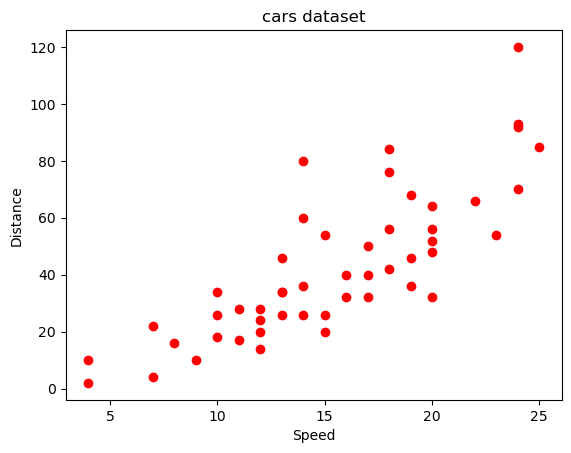

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Fri, 12 Sep 2025   Prob (F-statistic):           1.49e-12
Time:                        07:39:14   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.5791      6.758     -2.601      0.0

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:308: DomainWarning: The identity link function does not respect the domain of the Poisson family.
  warnings.warn((f"The {type(f

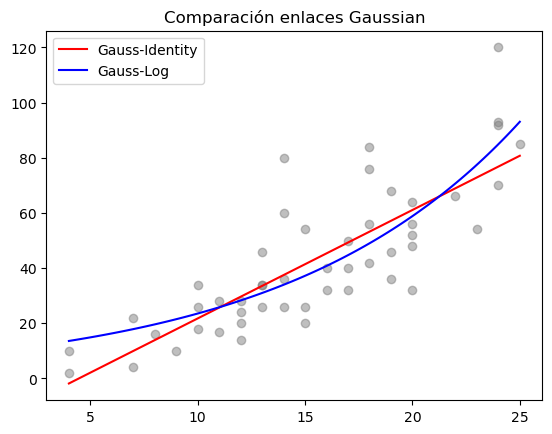

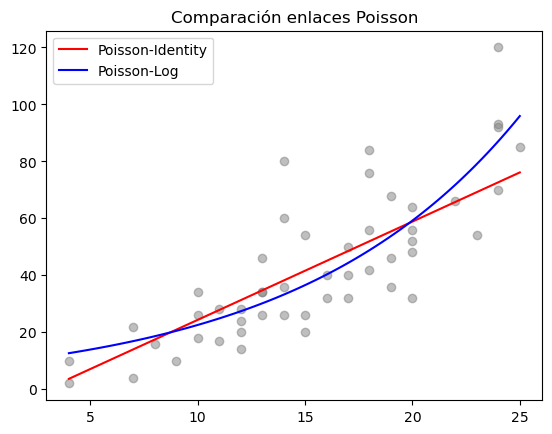

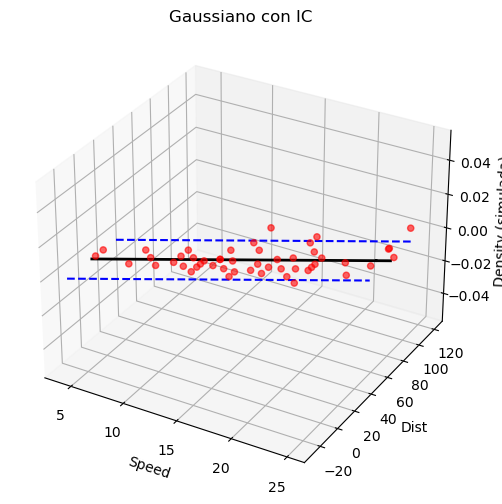

Errores: 4      2.119825
6     -3.744993
8     12.255007
13    -5.609810
29    -9.271854
37    10.863328
36   -11.136672
44   -18.866307
45    -6.798715
49     4.268876
dtype: float64
Densidad normal asociada: [0.02569449 0.02518198 0.01888375 0.02427026 0.02162935 0.02021273
 0.01995741 0.01222357 0.02352507 0.02495948]


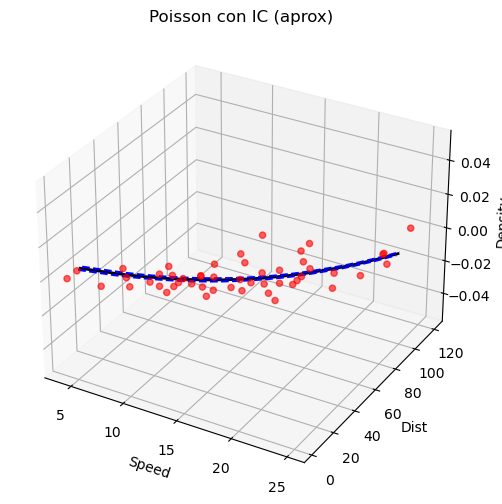

Errores Poisson: 4     -2.596631
6     -4.555642
8     11.444358
13    -3.357483
29    -4.322931
37    14.241220
36    -7.758780
44   -25.084481
45   -17.096707
49   -10.920670
dtype: float64
Densidad Poisson asociada: [0.00000000e+00 0.00000000e+00 4.63517218e-03 0.00000000e+00
 0.00000000e+00 6.95439905e-12 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


In [14]:
try:
    %run 02_lm_glm.py
except Exception as e:
    print("Nota: Ajusta la ruta o importa funciones desde 02_lm_glm.py. Error:", e)


### 1.3 Exposición (años-póliza) → `03_exposicion.py`
- La **exposición** es crítica: normaliza la frecuencia y permite comparaciones justas.
- Ajusta cancelaciones, pólizas cortas y vigencias parciales.



In [16]:
import numpy as np, pandas as pd
import statsmodels.formula.api as smf

def days_diff(end_ts, start_ts) -> int:
    return int((np.datetime64(end_ts, 'ns') - np.datetime64(start_ts, 'ns')) / np.timedelta64(1, 'D'))

def trunc_exp_days(rng: np.random.Generator, rate: float) -> int:
    return int(np.floor(rng.exponential(1.0 / rate)))

rng = np.random.default_rng(1)
n = 1000
D1 = pd.Timestamp("2003-01-01")
D2 = pd.Timestamp("2023-12-31")
mean_gap = 1000.0
rate = 1.0 / mean_gap

L = pd.date_range(D1, D2, freq="D")
ingreso = rng.choice(L, size=n, replace=True)
salida = np.array([D2] * n, dtype="datetime64[ns]")

def sim_siniestros_sin_cancel(ingreso_i, end_i, rng, rate):
    expo_c = days_diff(end_i, ingreso_i)
    w = [0]
    while max(w) < expo_c:
        w.append(w[-1] + 1 + trunc_exp_days(rng, rate))
    N = max(0, len(w) - 2)
    expo = expo_c
    return expo, N

expo_1, N_1 = np.zeros(n, dtype=int), np.zeros(n, dtype=int)
for i in range(n):
    e, c = sim_siniestros_sin_cancel(ingreso[i], salida[i], rng, rate)
    expo_1[i], N_1[i] = e, c

df1 = pd.DataFrame({"E": expo_1/365, "N": N_1})
reg1 = smf.glm("N ~ np.log(E)", data=df1, family=sm.families.Poisson(),
               offset=np.log(df1["E"])).fit()
print(reg1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      N   No. Observations:                 1000
Model:                            GLM   Df Residuals:                      998
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1899.5
Date:                Fri, 12 Sep 2025   Deviance:                       1078.2
Time:                        07:42:05   Pearson chi2:                 1.05e+03
No. Iterations:                     6   Pseudo R-squ. (CS):           0.002969
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1482      0.087    -13.218      0.0

In [19]:

try:
    %run 03_exposicion.py
except Exception as e:
    print("Nota: Ajusta la ruta o importa funciones desde 03_exposicion.py. Error:", e)



=== Escenario 1: sin cancelaciones ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      N   No. Observations:                 1000
Model:                            GLM   Df Residuals:                      998
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1899.5
Date:                Fri, 12 Sep 2025   Deviance:                       1078.2
Time:                        07:42:31   Pearson chi2:                 1.05e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.8001
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   


### 1.3 Segmentación básica → `04_segmentacion.py`
- Construye tablas por **edad, zona, género** (u otros factores del dataset).
- Devuelve **frecuencia**, **severidad** y **prima pura** por segmento.


In [20]:
import matplotlib.pyplot as plt

color = "#003366"; fill = "#99CCFF"

regglm0 = smf.glm("num_sin ~ 1", data=base_trabajo, family=sm.families.Poisson(),
                  offset=np.log(base_trabajo["EXPO"])).fit()
print(regglm0.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                num_sin   No. Observations:                50000
Model:                            GLM   Df Residuals:                    49999
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8175.3
Date:                Fri, 12 Sep 2025   Deviance:                       12680.
Time:                        07:43:04   Pearson chi2:                 9.86e+04
No. Iterations:                     7   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.6201      0.023   -114.928      0.0

[Modelo 0] Tasa global: 0.07279294596542157
                 Generalized Linear Model Regression Results                  
Dep. Variable:                num_sin   No. Observations:                50000
Model:                            GLM   Df Residuals:                    49999
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8175.3
Date:                Fri, 12 Sep 2025   Deviance:                       12680.
Time:                        07:43:15   Pearson chi2:                 9.86e+04
No. Iterations:                     7   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercep

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)
c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                num_sin   No. Observations:                50000
Model:                            GLM   Df Residuals:                    49998
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8156.6
Date:                Fri, 12 Sep 2025   Deviance:                       12642.
Time:                        07:43:16   Pearson chi2:                 9.68e+04
No. Iterations:                     7   Pseudo R-squ. (CS):          0.0007474
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.1631      0.077    -27.

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                num_sin   No. Observations:                50000
Model:                            GLM   Df Residuals:                    49983
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8132.5
Date:                Fri, 12 Sep 2025   Deviance:                       12594.
Time:                        07:43:19   Pearson chi2:                 9.69e+04
No. Iterations:                    19   Pseudo R-squ. (CS):           0.001712
Covariance Type:            nonrobust                                         
                                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                num_sin   No. Observations:                50000
Model:                            GLM   Df Residuals:                    49991
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8136.6
Date:                Fri, 12 Sep 2025   Deviance:                       12602.
Time:                        07:43:20   Pearson chi2:                 9.69e+04
No. Iterations:                    19   Pseudo R-squ. (CS):           0.001546
Covariance Type:            nonrobust                                         
                                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                num_sin   No. Observations:                50000
Model:                            GLM   Df Residuals:                    49993
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8136.9
Date:                Fri, 12 Sep 2025   Deviance:                       12603.
Time:                        07:43:20   Pearson chi2:                 9.69e+04
No. Iterations:                     7   Pseudo R-squ. (CS):           0.001535
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


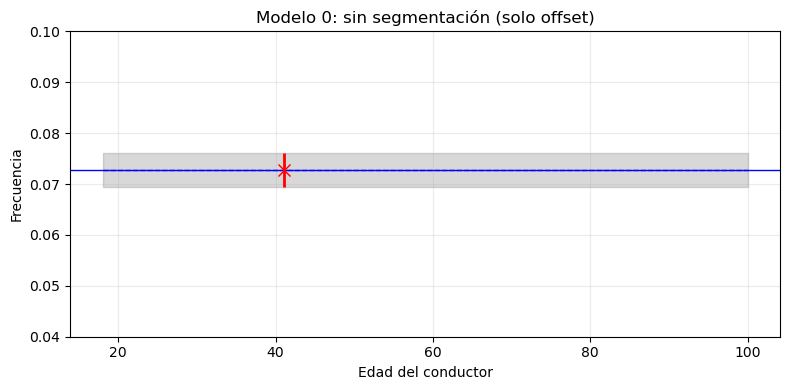

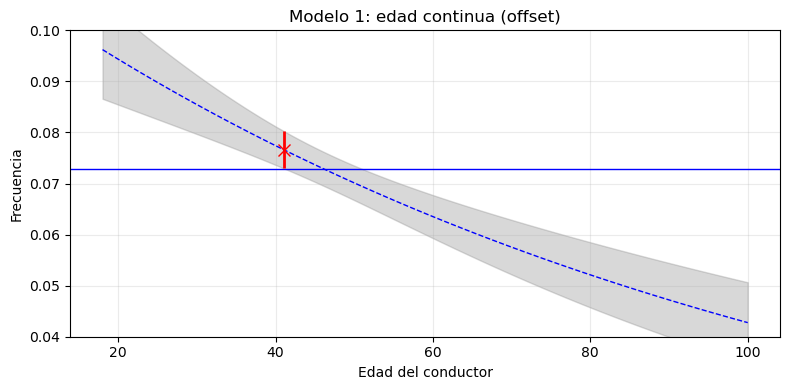

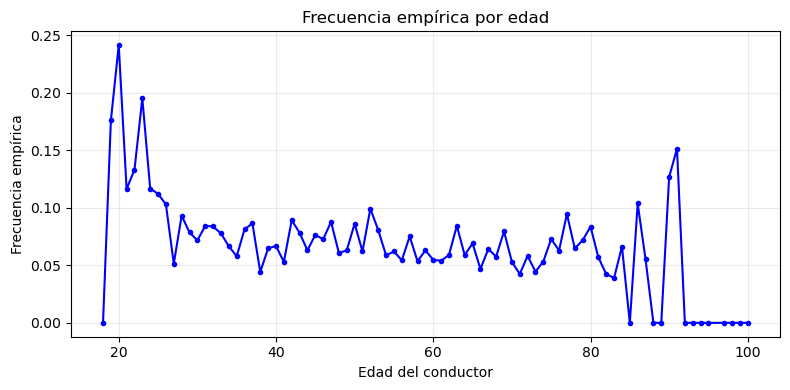

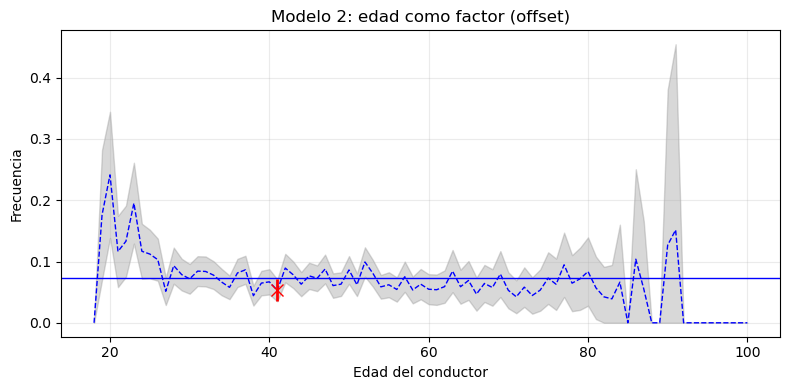

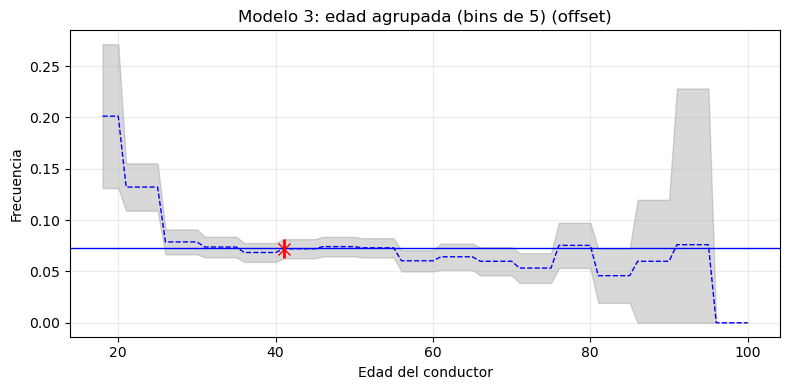

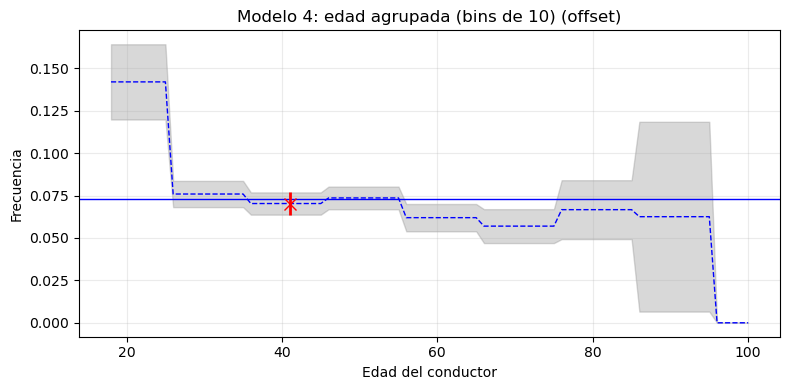

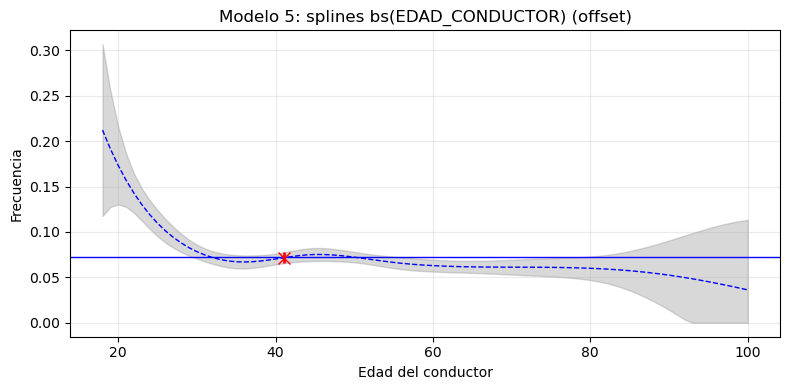

In [21]:

try:
    %run 04_segmentacion.py
except Exception as e:
    print("Nota: Ajusta la ruta o importa funciones desde 04_segmentacion.py. Error:", e)


## 1.5 Sobredispersión y elección de la distribución → `05_dispersión.py`

- Chequea si la **Poisson** es adecuada o si hay **sobredispersión**.
- Compara con **Binomial Negativa** y otras alternativas.   


In [22]:

sum_expo = base_trabajo["EXPO"].sum()
m_N = base_trabajo["num_sin"].sum() / sum_expo
s2_N = ((base_trabajo["num_sin"] - m_N * base_trabajo["EXPO"])**2).sum() / sum_expo
disp_total = s2_N / m_N
print({"m_N": m_N, "s2_N": s2_N, "dispersion": disp_total})

regpoisson = smf.glm("num_sin ~ EDAD_CONDUCTOR", data=base_trabajo, family=sm.families.Poisson(),
                     offset=np.log(base_trabajo["EXPO"])).fit()
print(regpoisson.summary())

{'m_N': 0.07279294596542157, 's2_N': 0.08778567195552542, 'dispersion': 1.2059639954292516}
                 Generalized Linear Model Regression Results                  
Dep. Variable:                num_sin   No. Observations:                50000
Model:                            GLM   Df Residuals:                    49998
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8156.6
Date:                Fri, 12 Sep 2025   Deviance:                       12642.
Time:                        07:44:47   Pearson chi2:                 9.68e+04
No. Iterations:                     7   Pseudo R-squ. (CS):          0.0007474
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

{'m_N': 0.07279294596542157, 's2_N': 0.08778567195552542, 'dispersion': 1.2059639954292516}

[EDA por COMBUSTIBLE]
   COMBUSTIBLE       m_N      s2_N          expo  dispersion
0           D  0.079715  0.087014  12519.548937    1.091560
1           E  0.066563  0.088421  13911.583565    1.328373

[WLS] s2_N ~ 0 + m_N, pesos=expo
                                 WLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.748
Model:                            WLS   Adj. R-squared (uncentered):              0.744
Method:                 Least Squares   F-statistic:                              239.9
Date:                Fri, 12 Sep 2025   Prob (F-statistic):                    6.23e-26
Time:                        07:49:28   Log-Likelihood:                          87.175
No. Observations:                  82   AIC:                                     -172.3
Df Residuals:                      81   BIC:          

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['loglike_method']
  warnings.warn(msg, ValueWarning)



[NB2 discreto] (estima parámetro de dispersión)


c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['loglike_method']
  warnings.warn(msg, ValueWarning)


                     NegativeBinomialP Regression Results                     
Dep. Variable:                      y   No. Observations:                50000
Model:              NegativeBinomialP   Df Residuals:                    49998
Method:                           MLE   Df Model:                            1
Date:                Fri, 12 Sep 2025   Pseudo R-squ.:               5.339e-05
Time:                        07:49:30   Log-Likelihood:                -8207.7
converged:                       True   LL-Null:                       -8208.1
Covariance Type:            nonrobust   LLR p-value:                    0.3492
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -3.1854      0.081    -39.548      0.000      -3.343      -3.028
EDAD_CONDUCTOR    -0.0016      0.002     -0.936      0.349      -0.005       0.002
alpha              2.6622      0.329

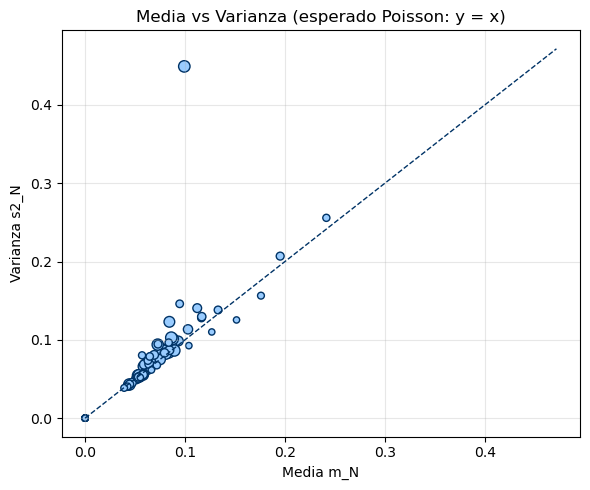

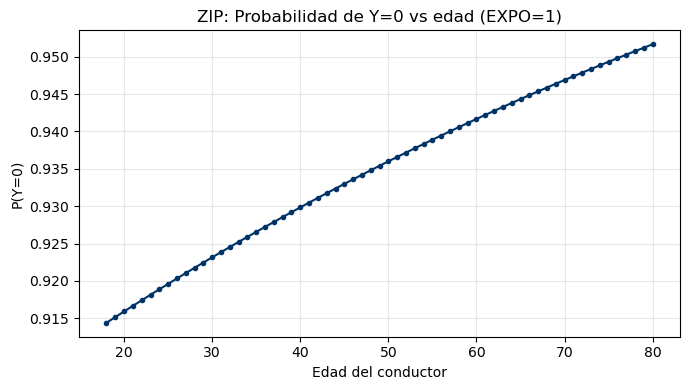

In [27]:
try:
    %run 05_dispersion.py
except Exception as e:
    print("Nota: Ajusta la ruta o importa funciones desde 05_dispersion.py. Error:", e)


## 2. Minidataset de ejemplo (AUTOS)
Para la sesión en vivo, generamos un dataset pequeño que **respete las tasas y costos medios** de DM, RC y RT, de forma que pueda verse la **heterocedasticidad** y la **segmentación**.


In [23]:

import numpy as np
import pandas as pd

np.random.seed(123)
n = 5000  # tamaño de muestra

# Segmentos simples
edad = np.random.choice(["Joven","Adulto"], size=n, p=[0.35, 0.65])
zona = np.random.choice(["CDMX","Interior"], size=n, p=[0.4, 0.6])
genero = np.random.choice(["H","M"], size=n, p=[0.55, 0.45])

# Exposición (años-póliza) ~ 0.5 a 1.0
exposicion = np.random.uniform(0.5, 1.0, size=n)

# Probabilidades base por cobertura (frecuencia)
p_DM = 0.159
p_RC = 0.085
p_RT = 0.0042

# Ajustes por segmento (ilustrativos)
mult_edad = np.where(edad=="Joven", 1.3, 1.0)
mult_zona = np.where(zona=="CDMX", 1.2, 1.0)
mult_genero = np.where(genero=="H", 1.1, 1.0)

# Frecuencia efectiva (cap para evitar >1)
p_DM_eff = np.clip(p_DM * mult_edad * mult_zona * mult_genero, 0, 0.9)
p_RC_eff = np.clip(p_RC * mult_edad * mult_zona * mult_genero, 0, 0.9)
p_RT_eff = np.clip(p_RT * mult_edad * mult_zona * mult_genero, 0, 0.2)

# Severidades medias (MXN)
sev_DM = 22023
sev_RC = 17147
sev_RT = 206984

# Simulación de ocurrencia por cobertura (Bernoulli con p * exposición aprox.)
DM = np.random.binomial(1, np.clip(p_DM_eff*exposicion,0,1))
RC = np.random.binomial(1, np.clip(p_RC_eff*exposicion,0,1))
RT = np.random.binomial(1, np.clip(p_RT_eff*exposicion,0,1))

# Monto con lognormal (ajustamos para que media aprox. coincida)
def lognorm_from_mean_sigma(mean, sigma):
    # para una lognormal con parámetros (mu, sigma): mean = exp(mu + sigma^2/2)
    # -> mu = log(mean) - sigma^2/2
    mu = np.log(mean) - (sigma**2)/2.0
    return mu, sigma

mu_DM, s_DM = lognorm_from_mean_sigma(sev_DM, 0.35)
mu_RC, s_RC = lognorm_from_mean_sigma(sev_RC, 0.45)
mu_RT, s_RT = lognorm_from_mean_sigma(sev_RT, 0.60)

monto_DM = np.where(DM==1, np.random.lognormal(mu_DM, s_DM, size=n), 0.0)
monto_RC = np.where(RC==1, np.random.lognormal(mu_RC, s_RC, size=n), 0.0)
monto_RT = np.where(RT==1, np.random.lognormal(mu_RT, s_RT, size=n), 0.0)

df = pd.DataFrame({
    "edad": edad, "zona": zona, "genero": genero, "exposicion": exposicion,
    "DM": DM, "monto_DM": monto_DM,
    "RC": RC, "monto_RC": monto_RC,
    "RT": RT, "monto_RT": monto_RT
})

# Agregar totales por póliza
df["siniestros"] = df[["DM","RC","RT"]].sum(axis=1)
df["monto"] = df[["monto_DM","monto_RC","monto_RT"]].sum(axis=1)

df.head()


,edad,zona,genero,exposicion,DM,monto_DM,RC,monto_RC,RT,monto_RT,siniestros,monto
0,Adulto,Interior,M,0.970149,0,0.0,0,0.000000,0,0.0,0,0.000000
1,Joven,CDMX,M,0.849002,0,0.0,0,0.000000,0,0.0,0,0.000000
2,Joven,Interior,M,0.756745,0,0.0,1,12041.413048,0,0.0,1,12041.413048
3,Adulto,Interior,H,0.889616,0,0.0,1,25543.836717,0,0.0,1,25543.836717
4,Adulto,Interior,H,0.729416,0,0.0,0,0.000000,0,0.0,0,0.000000



## 3. Heterocedasticidad (abanico) y tablas media–varianza por segmento
Visualizamos el patrón típico en seguros: **la varianza crece con la media** (especialmente por RT).


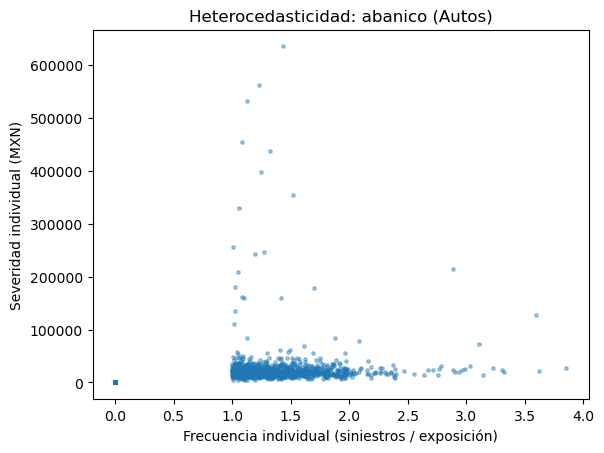

In [24]:

import matplotlib.pyplot as plt

# Frecuencia y severidad por registro
freq_indiv = df["siniestros"] / df["exposicion"]
sev_indiv = np.where(df["siniestros"]>0, df["monto"]/df["siniestros"], 0.0)

plt.scatter(freq_indiv, sev_indiv, s=6, alpha=0.4)
plt.xlabel("Frecuencia individual (siniestros / exposición)")
plt.ylabel("Severidad individual (MXN)")
plt.title("Heterocedasticidad: abanico (Autos)")
plt.show()


In [25]:

# Tablas por segmento (edad, zona, género)
grp = df.groupby(["edad","zona","genero"]).agg(
    exp=("exposicion","sum"),
    sin=("siniestros","sum"),
    monto=("monto","sum")
).reset_index()

grp["freq"] = grp["sin"] / grp["exp"]
grp["sev"] = grp.apply(lambda r: (r["monto"]/r["sin"]) if r["sin"]>0 else 0.0, axis=1)
grp["prima_pura"] = grp["freq"] * grp["sev"]
grp.sort_values("prima_pura", ascending=False)


,edad,zona,genero,exp,sin,monto,freq,sev,prima_pura
6,Joven,Interior,H,464.809214,162,5.196180e+06,0.348530,32075.185167,11179.167365
4,Joven,CDMX,H,271.480026,120,2.749872e+06,0.442021,22915.599426,10129.186932
7,Joven,Interior,M,358.753802,125,3.379593e+06,0.348428,27036.741229,9420.367485
1,Adulto,CDMX,M,443.935568,141,3.648397e+06,0.317614,25875.155484,8218.302801
0,Adulto,CDMX,H,532.325814,160,4.146354e+06,0.300568,25914.711577,7789.127902
5,Joven,CDMX,M,241.349737,79,1.863681e+06,0.327326,23590.902720,7721.911509
2,Adulto,Interior,H,767.313180,204,5.774802e+06,0.265863,28307.854697,7526.004381
3,Adulto,Interior,M,676.026285,154,3.332084e+06,0.227802,21636.910976,4928.927119
